Number of cereals after cleaning: 74

=== Correlation Matrix of Features ===
          calories   protein       fat    sodium     fiber     carbo  \
calories  1.000000  0.033992  0.507373  0.296247 -0.295212  0.270606   
protein   0.033992  1.000000  0.202353  0.011559  0.514006 -0.036743   
fat       0.507373  0.202353  1.000000  0.000822  0.014036 -0.284934   
sodium    0.296247  0.011559  0.000822  1.000000 -0.070735  0.328409   
fiber    -0.295212  0.514006  0.014036 -0.070735  1.000000 -0.379084   
carbo     0.270606 -0.036743 -0.284934  0.328409 -0.379084  1.000000   
sugars    0.569121 -0.286584  0.287152  0.037059 -0.150949 -0.452069   
potass   -0.071361  0.578743  0.199637 -0.039438  0.911504 -0.365003   

            sugars    potass  
calories  0.569121 -0.071361  
protein  -0.286584  0.578743  
fat       0.287152  0.199637  
sodium    0.037059 -0.039438  
fiber    -0.150949  0.911504  
carbo    -0.452069 -0.365003  
sugars    1.000000  0.001414  
potass    0.001414  1.0000

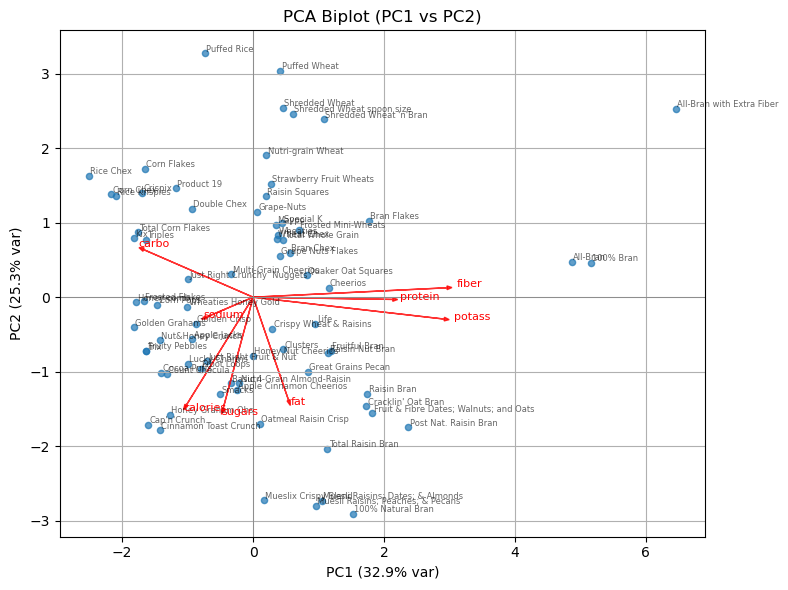

PCA Model regression: rating ≈ 5.148×PC1 + 7.325×PC2 + (42.372)

=== Model Comparison Table ===
     Model       R2      MAE  Alex_Error
Full Model 0.994574 0.611176    0.223087
Sugar Only 0.571468 7.087819   34.033980
 PCA Model 0.916519 3.074205    0.448064

Alex's cereal ('All-Bran with Extra Fiber') true rating = 93.70
 Full Model predicted = 93.93, error = 0.22
 Sugar Only predicted = 59.67, error = 34.03
 PCA Model predicted = 94.15, error = 0.45


=== PC1‐Only Model Evaluation ===
R2 = 0.3585
MAE = 9.2581
Alex's cereal predicted = 75.64, error = 18.07

PC1‐Only regression: rating ≈ 5.148×PC1 + (42.372)

=== Top 5 Cereals by PC1‐Only Predicted Rating ===
                                  name  sugars  fat  fiber  Pred_PC1
             All-Bran with Extra Fiber     0.0    0   14.0 75.636815
                             100% Bran     6.0    1   10.0 68.921107
                              All-Bran     5.0    1    9.0 67.460314
                 Post Nat. Raisin Bran    14.0    1    

In [ ]:
# pca_cereal_with_model_comparison.py

import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

def main():
    # ====================================
    # 1. Read data 
    # ====================================
    df = pd.read_csv("cereal.csv")
    
    # The Kaggle “80 Cereals” dataset has these relevant columns:
    #   - name      (string)
    #   - calories  (numeric)
    #   - protein   (numeric)
    #   - fat       (numeric)
    #   - sodium    (numeric)
    #   - fiber     (numeric)
    #   - carbo     (numeric)
    #   - sugars    (numeric)
    #   - potass    (numeric)
    #   - rating    (numeric, “health rating” we will predict)
    
  
    
    # ====================================
    # 2. Choose predictor columns and target
    # ====================================
    feature_cols = ['calories', 'protein', 'fat', 'sodium', 'fiber', 'carbo', 'sugars', 'potass']
    target_col   = 'rating'
    
    # Drop any rows where any of these 9 columns is missing or marked = -1
    df_clean = df.loc[:, ['name'] + feature_cols + [target_col]] \
                  .replace(-1, np.nan) \
                  .dropna(axis=0, how='any') \
                  .reset_index(drop=True)
    
    # Extract X (matrix of shape [n_samples, 8]) and y ([n_samples])
    X_df = df_clean[feature_cols].copy()
    y    = df_clean[target_col].values                # shape = (n_samples,)
    names = df_clean['name'].values                   # cereal names for later
    
    print(f"Number of cereals after cleaning: {len(df_clean)}\n")
    
    # ====================================
    # 3. Correlation matrix 
    # ====================================
    print("=== Correlation Matrix of Features ===")
    print(X_df.corr(), "\n")
    
    # ====================================
    # 4. Standardize features
    # ====================================
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X_df)  # shape = (n_samples, 8)
    
    # ====================================
    # 5. Fit a “full” PCA (8 components), print eigen‐stuff
    # ====================================
    pca_full = PCA(n_components=8)
    pca_full.fit(X_std)
    
    print("=== Eigenvalues (PCA full) ===")
    print(pca_full.explained_variance_, "\n")  # length = 8
    
    loadings = pd.DataFrame(
        pca_full.components_.T,
        index=feature_cols,
        columns=[f"PC{i+1}" for i in range(8)]
    )
    print("=== Eigenvectors = PCA loadings (features × PCs) ===")
    print(loadings, "\n")
    
    print("=== PCA loadings（only PC1 & PC2）===")
    print(loadings.loc[:, ["PC1", "PC2"]].round(4))
    print()  
    
    print("=== Explained Variance Ratios ===")
    for i, ratio in enumerate(pca_full.explained_variance_ratio_, start=1):
        print(f"PC{i}: {ratio:.4f} ({ratio*100:.1f}%)")
    print()
    
    # ====================================
    # 6. Reduce to 2 PCs for plotting & PCA model
    # ====================================
    pca2 = PCA(n_components=2)
    X_pca2 = pca2.fit_transform(X_std)  # shape = (n_samples, 2)
    
    # ====================================
    # 7. Plot the PCA biplot (PC1 vs PC2)
    # ====================================
    plt.figure(figsize=(8,6))
    plt.scatter(X_pca2[:,0], X_pca2[:,1], alpha=0.7, s=20, color='tab:blue')
    for i, nm in enumerate(names):
        plt.text(X_pca2[i,0]+0.02, X_pca2[i,1]+0.02, nm, fontsize=6, alpha=0.6)
    
    comps = pca2.components_.T  # shape = (8,2)
    scale_x = X_pca2[:,0].max() * 0.8
    scale_y = X_pca2[:,1].max() * 0.8
    
    for i, feat in enumerate(feature_cols):
        plt.arrow(0, 0,
                  comps[i,0] * scale_x,
                  comps[i,1] * scale_y,
                  color='red', alpha=0.8, head_width=0.05)
        plt.text(comps[i,0]*scale_x*1.05,
                 comps[i,1]*scale_y*1.05,
                 feat, color='red', fontsize=8)
    
    plt.axhline(0, color='grey', linewidth=0.5)
    plt.axvline(0, color='grey', linewidth=0.5)
    plt.xlabel(f"PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)")
    plt.ylabel(f"PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)")
    plt.title("PCA Biplot (PC1 vs PC2)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # ====================================
    # 8. Model Comparison: build four regression models
    # ====================================
    
    # 8a. Full Model (all 8 features)
    model_full = LinearRegression().fit(X_df.values, y)
    y_pred_full = model_full.predict(X_df.values)
    
    # 8b. Sugar Only Model
    X_sugar = X_df[['sugars']].values.reshape(-1,1)  # shape = (n_samples,1)
    model_sugar = LinearRegression().fit(X_sugar, y)
    y_pred_sugar = model_sugar.predict(X_sugar)

    # 8c. PCA Model (only PC1 and PC2 as predictors)
    X_pc = X_pca2  # already shape = (n_samples, 2)
    model_pca = LinearRegression().fit(X_pc, y)
    y_pred_pca = model_pca.predict(X_pc)
    
    coef_pc1_pca = model_pca.coef_[0]   # PC1 coef
    coef_pc2_pca = model_pca.coef_[1]   # PC2 coef
    intercept_pca = model_pca.intercept_
    print(f"PCA Model regression: rating ≈ {coef_pc1_pca:.3f}×PC1 + {coef_pc2_pca:.3f}×PC2 + ({intercept_pca:.3f})")
    print()
    
    # 8d. Compute metrics for each model on the entire dataset
    results = pd.DataFrame({
        'Model': ['Full Model', 'Sugar Only', 'PCA Model'],
        'R2': [
            r2_score(y, y_pred_full),
            r2_score(y, y_pred_sugar),
            r2_score(y, y_pred_pca)
        ],
        'MAE': [
            mean_absolute_error(y, y_pred_full),
            mean_absolute_error(y, y_pred_sugar),
            mean_absolute_error(y, y_pred_pca)
        ]
    })
    
    # 8e. Find “Alex’s cereal” (All-Bran with Extra Fiber) and compute prediction errors
    mask_alex = (df_clean['name'] == 'All-Bran with Extra Fiber')
    if not mask_alex.any():
        mask_alex = (df_clean['name'].str.lower() == 'all-bran with extra fiber')
    idx_alex = np.where(mask_alex)[0]
    if len(idx_alex) != 1:
        print("⚠️ Warning: Could not find exactly one row named 'All-Bran with Extra Fiber'.")
        idx_alex = [0]  # fallback to first cereal if not found
    idx_alex = idx_alex[0]
    
    # True rating
    y_alex_true = y[idx_alex]
    
    # Build feature‐vectors for Alex
    x_alex_full  = X_df.values[idx_alex].reshape(1, -1)
    x_alex_sugar = np.array([[ X_df.loc[idx_alex, 'sugars'] ]])
    x_alex_pc    = X_pc[idx_alex].reshape(1, -1)
    
    # Predictions for Alex's cereal under each model
    alex_pred_full  = model_full.predict(x_alex_full)[0]
    alex_pred_sugar = model_sugar.predict(x_alex_sugar)[0]
    alex_pred_pca   = model_pca.predict(x_alex_pc)[0]
    
    # Add Alex's error to results
    errors_for_alex = [
        abs(y_alex_true - alex_pred_full),
        abs(y_alex_true - alex_pred_sugar),
        abs(y_alex_true - alex_pred_pca)
    ]
    results['Alex_Error'] = errors_for_alex
    
    print("=== Model Comparison Table ===")
    print(results.to_string(index=False))
    print(f"\nAlex's cereal ('All-Bran with Extra Fiber') true rating = {y_alex_true:.2f}")
    print(f" Full Model predicted = {alex_pred_full:.2f}, error = {errors_for_alex[0]:.2f}")
    print(f" Sugar Only predicted = {alex_pred_sugar:.2f}, error = {errors_for_alex[1]:.2f}")
    print(f" PCA Model predicted = {alex_pred_pca:.2f}, error = {errors_for_alex[2]:.2f}\n")
    print()
    

    # ====================================
    # 9. Predict 'rating' Using Only PC1
    # ====================================

    X_pc1 = X_pca2[:, 0].reshape(-1, 1)  # shape = (n_samples, 1)
    model_pc1 = LinearRegression().fit(X_pc1, y)
    y_pred_pc1 = model_pc1.predict(X_pc1)

    r2_pc1 = r2_score(y, y_pred_pc1)
    mae_pc1 = mean_absolute_error(y, y_pred_pc1)
    x_alex_pc1 = np.array([[ X_pc[idx_alex, 0] ]])  
    alex_pred_pc1 = model_pc1.predict(x_alex_pc1)[0]
    error_alex_pc1 = abs(y_alex_true - alex_pred_pc1)

    print("=== PC1‐Only Model Evaluation ===")
    print(f"R2 = {r2_pc1:.4f}")
    print(f"MAE = {mae_pc1:.4f}")
    print(f"Alex's cereal predicted = {alex_pred_pc1:.2f}, error = {error_alex_pc1:.2f}")
    print()

    coef_pc1 = model_pc1.coef_[0]
    intercept_pc1 = model_pc1.intercept_
    print(f"PC1‐Only regression: rating ≈ {coef_pc1:.3f}×PC1 + ({intercept_pc1:.3f})")
    print()
    
    df_clean['Pred_PC1'] = y_pred_pc1
    df_pred_sorted = df_clean.sort_values('Pred_PC1', ascending=False).reset_index(drop=True)
    print("=== Top 5 Cereals by PC1‐Only Predicted Rating ===")
    print(df_pred_sorted.loc[:4, ['name','sugars','fat','fiber','Pred_PC1']].to_string(index=False))
    print()
    
    # ====================================
    # 10. Predict 'rating' by PCA Model (PC1+PC2) 
    # ====================================
    # PCA Model (PC1+PC2) Evaluation
    r2_pca = r2_score(y, y_pred_pca)
    mae_pca = mean_absolute_error(y, y_pred_pca)
    alex_pred_pca_val = alex_pred_pca  # already computed earlier
    error_alex_pca = abs(y_alex_true - alex_pred_pca_val)

    print("=== PCA Model (PC1+PC2) Evaluation ===")
    print(f"R2 = {r2_pca:.4f}")
    print(f"MAE = {mae_pca:.4f}")
    print(f"Alex's cereal predicted = {alex_pred_pca_val:.2f}, error = {error_alex_pca:.2f}\n")
    print(f"PCA Model regression: rating ≈ {coef_pc1_pca:.3f}×PC1 + {coef_pc2_pca:.3f}×PC2 + ({intercept_pca:.3f})\n")
    
    # Top 5 Cereals by PCA (PC1+PC2) Predicted Rating
    df_clean['Pred_PCA'] = y_pred_pca
    df_pred_sorted_pca = df_clean.sort_values('Pred_PCA', ascending=False).reset_index(drop=True)
    print("=== Top 5 Cereals by PCA (PC1+PC2) Predicted Rating ===")
    print(df_pred_sorted_pca.loc[:4, ['name','sugars','fat','fiber','Pred_PCA']].to_string(index=False))

if __name__ == "__main__":
    main()   

